In [1]:
!pip install kagglehub -q

import os, glob, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_curve, auc, precision_recall_curve)

import kagglehub
path = kagglehub.dataset_download("aletbm/aerial-imagery-dataset-floodnet-challenge")
track1 = os.path.join(path, 'FloodNet Challenge - Track 1')
print("Dataset root:", track1)

100%|██████████| 23.3G/23.3G [04:54<00:00, 85.0MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/versions/1/FloodNet Challenge - Track 1


In [2]:
labeled_dir = os.path.join(track1, 'Train', 'Labeled')

flooded_files = glob.glob(os.path.join(labeled_dir, 'Flooded', 'image', '*'))
nonflooded_files = glob.glob(os.path.join(labeled_dir, 'Non-Flooded', 'image', '*'))

print("Flooded images:", len(flooded_files))
print("Non-flooded images:", len(nonflooded_files))

all_files = flooded_files + nonflooded_files
all_labels = [1] * len(flooded_files) + [0] * len(nonflooded_files)

Flooded images: 51
Non-flooded images: 347


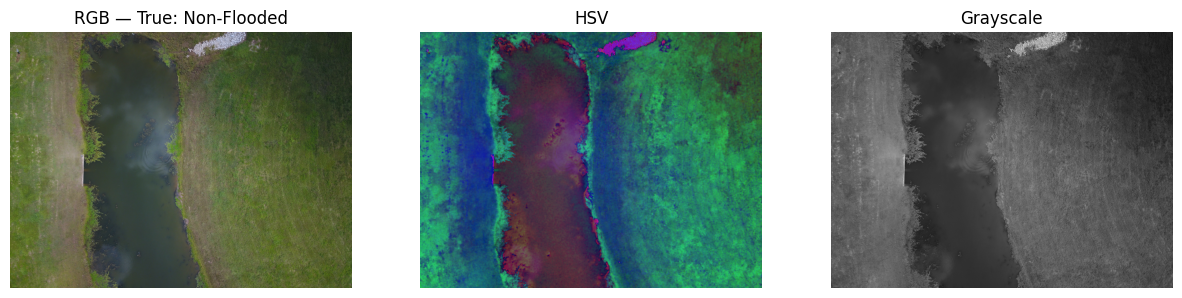

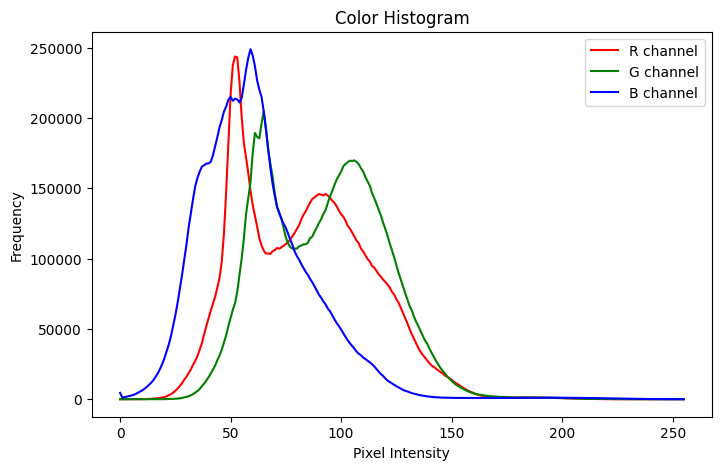

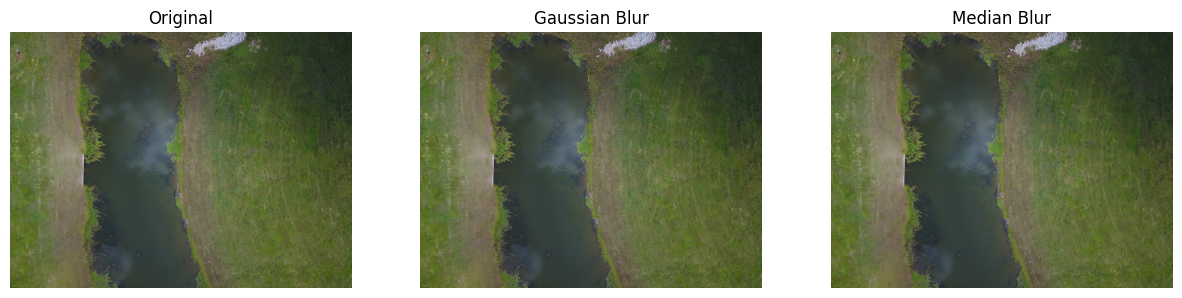

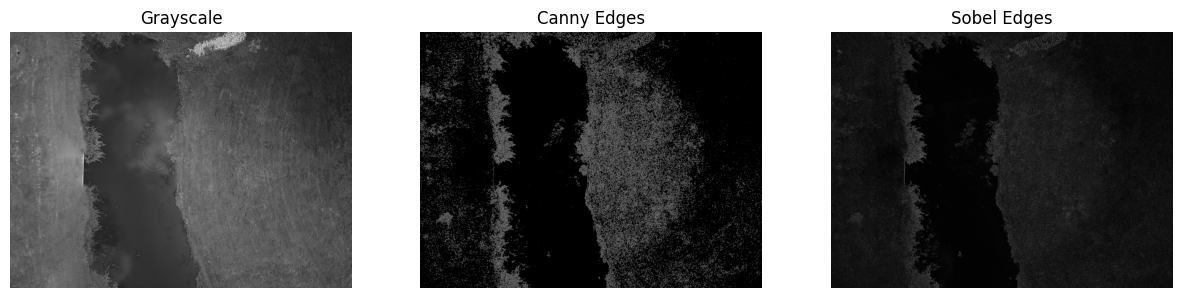

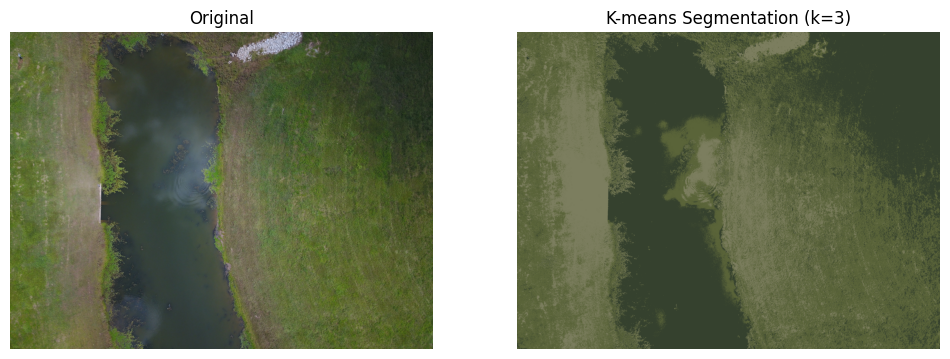

Cluster center colors (RGB):
Cluster 0: [ 90 100  57]
Cluster 1: [53 65 46]
Cluster 2: [124 126  95]


In [3]:
sample_path = random.choice(all_files)
sample_label = 'Flooded' if all_labels[all_files.index(sample_path)] == 1 else 'Non-Flooded'

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title(f"RGB — True: {sample_label}"); axes[0].axis('off')
axes[1].imshow(img_hsv); axes[1].set_title("HSV"); axes[1].axis('off')
axes[2].imshow(img_gray, cmap='gray'); axes[2].set_title("Grayscale"); axes[2].axis('off')
plt.show()

# Histogram
colors = ('r', 'g', 'b')
plt.figure(figsize=(8, 5))
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
plt.title("Color Histogram")
plt.xlabel("Pixel Intensity"); plt.ylabel("Frequency"); plt.legend()
plt.show()

# Filtering
blurred_gaussian = cv2.GaussianBlur(img_rgb, (5, 5), 0)
blurred_median = cv2.medianBlur(img_rgb, 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(blurred_gaussian); axes[1].set_title("Gaussian Blur"); axes[1].axis('off')
axes[2].imshow(blurred_median); axes[2].set_title("Median Blur"); axes[2].axis('off')
plt.show()

# Edge detection
edges_canny = cv2.Canny(img_gray, 100, 200)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Grayscale"); axes[0].axis('off')
axes[1].imshow(edges_canny, cmap='gray'); axes[1].set_title("Canny Edges"); axes[1].axis('off')
axes[2].imshow(sobel_combined, cmap='gray'); axes[2].set_title("Sobel Edges"); axes[2].axis('off')
plt.show()

# K-means segmentation demo
pixels = img_rgb.reshape(-1, 3).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels_km, centers = cv2.kmeans(pixels, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
labels_km = labels_km.reshape(img_rgb.shape[:2])
centers = centers.astype(np.uint8)
segmented_img = centers[labels_km]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(segmented_img); axes[1].set_title("K-means Segmentation (k=3)"); axes[1].axis('off')
plt.show()
print("Cluster center colors (RGB):")
for i, c in enumerate(centers):
    print(f"Cluster {i}: {c}")

In [4]:
def extract_dip_features(file_path):
    img = cv2.imread(file_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = {}

    # 1. Water coverage via HSV thresholding + morphology
    lower_water = np.array([0, 20, 20])
    upper_water = np.array([30, 180, 200])
    water_mask = cv2.inRange(img_hsv, lower_water, upper_water)
    kernel = np.ones((5, 5), np.uint8)
    water_mask = cv2.morphologyEx(water_mask, cv2.MORPH_OPEN, kernel)
    water_mask = cv2.morphologyEx(water_mask, cv2.MORPH_CLOSE, kernel)
    features['water_coverage_pct'] = (np.sum(water_mask > 0) / water_mask.size) * 100

    # 2. Color histogram statistics (per channel mean/std — summarizes color distribution)
    for i, ch in enumerate(['R', 'G', 'B']):
        features[f'{ch}_mean'] = np.mean(img_rgb[:, :, i])
        features[f'{ch}_std'] = np.std(img_rgb[:, :, i])

    # 3. HSV statistics
    features['H_mean'] = np.mean(img_hsv[:, :, 0])
    features['S_mean'] = np.mean(img_hsv[:, :, 1])
    features['V_mean'] = np.mean(img_hsv[:, :, 2])

    # 4. Edge density (Canny) — texture/complexity indicator
    edges = cv2.Canny(img_gray, 100, 200)
    features['edge_density'] = np.sum(edges > 0) / edges.size

    # 5. Grayscale contrast (std deviation of intensity — murky flood areas tend to be flatter/less contrasty)
    features['gray_std'] = np.std(img_gray)
    features['gray_mean'] = np.mean(img_gray)

    return features

# Quick test on one image
print(extract_dip_features(all_files[0]))

{'water_coverage_pct': np.float64(38.17951765071501), 'R_mean': np.float64(115.03048900998566), 'R_std': np.float64(55.61177634475331), 'G_mean': np.float64(109.1131490426058), 'G_std': np.float64(47.696155861730425), 'B_mean': np.float64(84.6584611598069), 'B_std': np.float64(47.45762447222363), 'H_mean': np.float64(35.34392325194178), 'S_mean': np.float64(75.2325452213088), 'V_mean': np.float64(118.49803489481253), 'edge_density': np.float64(0.051341837706881534), 'gray_std': np.float64(49.22165754018798), 'gray_mean': np.float64(108.09649799980491)}


In [5]:
feature_rows = []
valid_labels = []

for f, l in zip(all_files, all_labels):
    feats = extract_dip_features(f)
    if feats is not None:
        feature_rows.append(feats)
        valid_labels.append(l)

df = pd.DataFrame(feature_rows)
df['label'] = valid_labels
print(df.shape)
df.head()

(398, 14)


,water_coverage_pct,R_mean,R_std,G_mean,G_std,B_mean,B_std,H_mean,S_mean,V_mean,edge_density,gray_std,gray_mean,label
0,38.179518,115.030489,55.611776,109.113149,47.696156,84.658461,47.457624,35.343923,75.232545,118.498035,0.051342,49.221658,108.096498,1
1,24.002695,105.617625,44.848325,108.722377,41.062732,96.464623,41.798503,55.025290,47.078131,113.233155,0.008648,41.590733,106.395574,1
2,48.690417,114.740439,47.684224,111.452308,32.015066,74.199818,34.723779,30.694950,105.123461,122.528492,0.005185,36.272067,108.188854,1
3,21.014702,97.527096,56.927006,98.117130,50.028908,91.459882,48.991231,68.102244,57.416866,107.141132,0.011644,51.254416,97.181960,1
4,32.326416,122.735868,51.329954,121.395666,46.242344,105.587409,47.240338,50.360710,53.374406,128.686369,0.061594,47.087914,119.998438,1


In [6]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Flooded in train/val/test: {y_train.sum()}/{y_val.sum()}/{y_test.sum()}")

# Scale features — important for SVM, harmless for Random Forest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: 287  Val: 51  Test: 60
Flooded in train/val/test: 37/6/8


In [7]:
# --- Random Forest: try a few depths, pick the best on validation ---
best_rf, best_rf_f1 = None, -1
for depth in [4, 6, 8, 10, None]:
    model = RandomForestClassifier(
        n_estimators=200, max_depth=depth, class_weight='balanced', random_state=42
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred)
    print(f"RF max_depth={depth} -> Validation F1: {val_f1:.3f}")
    if val_f1 > best_rf_f1:
        best_rf, best_rf_f1 = model, val_f1

print(f"\nBest Random Forest: max_depth chosen with Validation F1={best_rf_f1:.3f}")
rf_model = best_rf

# --- SVM: try a few C values, pick the best on validation ---
best_svm, best_svm_f1 = None, -1
for C in [0.1, 1, 10]:
    model = SVC(kernel='rbf', C=C, class_weight='balanced', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    val_pred = model.predict(X_val_scaled)
    val_f1 = f1_score(y_val, val_pred)
    print(f"SVM C={C} -> Validation F1: {val_f1:.3f}")
    if val_f1 > best_svm_f1:
        best_svm, best_svm_f1 = model, val_f1

print(f"\nBest SVM: C chosen with Validation F1={best_svm_f1:.3f}")
svm_model = best_svm

RF max_depth=4 -> Validation F1: 0.909
RF max_depth=6 -> Validation F1: 0.800
RF max_depth=8 -> Validation F1: 0.800
RF max_depth=10 -> Validation F1: 0.800
RF max_depth=None -> Validation F1: 0.800

Best Random Forest: max_depth chosen with Validation F1=0.909
SVM C=0.1 -> Validation F1: 0.750
SVM C=1 -> Validation F1: 0.857
SVM C=10 -> Validation F1: 0.909

Best SVM: C chosen with Validation F1=0.909


In [8]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Accuracy:", (y_pred == y_true).mean())
    print("F1 Score:", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['Non-Flooded', 'Flooded']))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return y_prob

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model("SVM", y_test, svm_pred, svm_prob)


Random Forest
Accuracy: 0.8833333333333333
F1 Score: 0.46153846153846156
              precision    recall  f1-score   support

 Non-Flooded       0.91      0.96      0.93        52
     Flooded       0.60      0.38      0.46         8

    accuracy                           0.88        60
   macro avg       0.75      0.67      0.70        60
weighted avg       0.87      0.88      0.87        60

Confusion matrix:
 [[50  2]
 [ 5  3]]

SVM
Accuracy: 0.9666666666666667
F1 Score: 0.8571428571428571
              precision    recall  f1-score   support

 Non-Flooded       0.96      1.00      0.98        52
     Flooded       1.00      0.75      0.86         8

    accuracy                           0.97        60
   macro avg       0.98      0.88      0.92        60
weighted avg       0.97      0.97      0.96        60

Confusion matrix:
 [[52  0]
 [ 2  6]]


array([4.49488287e-01, 1.95755129e-02, 1.00303964e-01, 6.45742521e-02,
       1.31899728e-02, 8.97495320e-03, 9.12310432e-03, 9.52113641e-04,
       4.62788757e-01, 4.81892231e-02, 1.71027245e-01, 2.98449302e-01,
       2.81595233e-02, 8.02777348e-04, 2.24950387e-02, 9.82125606e-03,
       3.72706603e-03, 2.92133647e-03, 4.50440169e-01, 9.55416075e-01,
       2.33779977e-02, 4.93500896e-03, 2.89785952e-02, 9.66953837e-03,
       6.29887976e-02, 5.00000000e-01, 1.60494847e-03, 2.68832586e-01,
       5.03261174e-03, 7.48593317e-03, 1.33322976e-01, 3.49921780e-03,
       9.54307365e-04, 2.66048798e-03, 8.34059374e-02, 1.64521056e-03,
       3.24335968e-02, 3.68933278e-02, 7.67069632e-03, 1.12251618e-02,
       4.80771012e-02, 4.24491248e-04, 4.66693033e-03, 1.53508062e-02,
       2.12359863e-03, 5.46959755e-03, 8.24327568e-03, 6.45092691e-02,
       3.02781358e-04, 3.36451135e-02, 1.11088545e-02, 6.83530176e-04,
       7.39307337e-02, 7.35183746e-03, 2.93605993e-02, 2.49801729e-03,
      

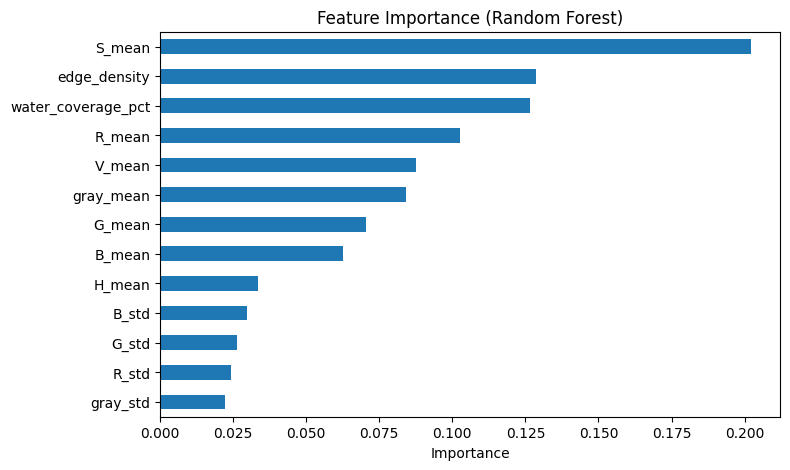

S_mean                0.202048
edge_density          0.128545
water_coverage_pct    0.126440
R_mean                0.102601
V_mean                0.087448
gray_mean             0.084312
G_mean                0.070352
B_mean                0.062507
H_mean                0.033542
B_std                 0.029587
G_std                 0.026165
R_std                 0.024212
gray_std              0.022242
dtype: float64


In [9]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()
print(importances)

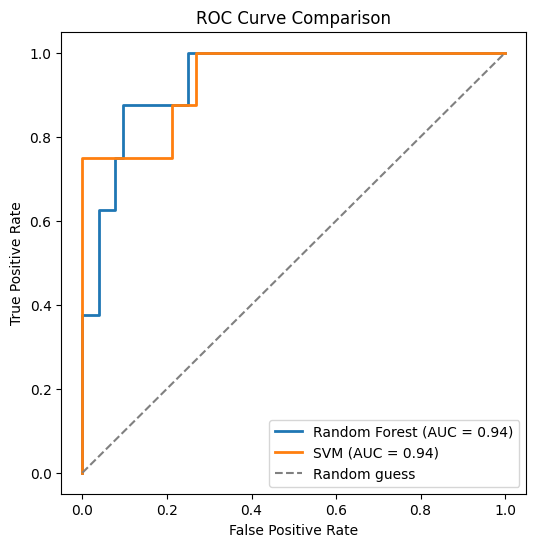

In [10]:
plt.figure(figsize=(6, 6))
for name, prob in [('Random Forest', rf_prob), ('SVM', svm_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

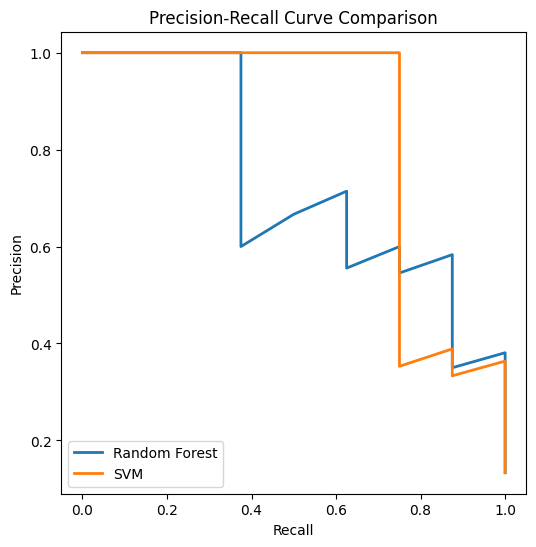

In [11]:
plt.figure(figsize=(6, 6))
for name, prob in [('Random Forest', rf_prob), ('SVM', svm_prob)]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name, linewidth=2)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

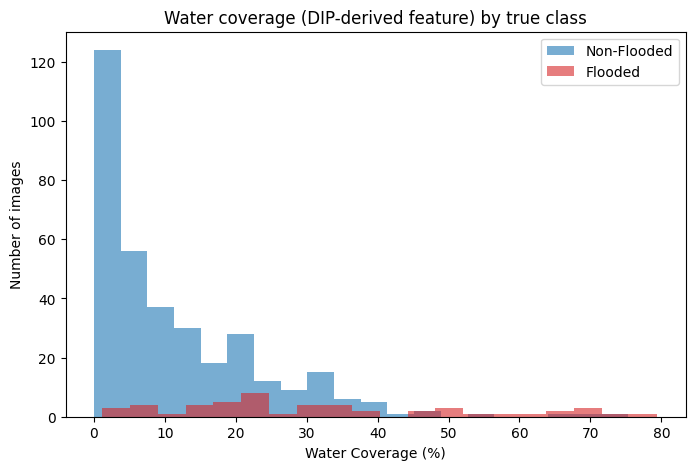

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df[df['label']==0]['water_coverage_pct'], bins=20, alpha=0.6, label='Non-Flooded', color='#1f77b4')
plt.hist(df[df['label']==1]['water_coverage_pct'], bins=20, alpha=0.6, label='Flooded', color='#d62728')
plt.xlabel("Water Coverage (%)"); plt.ylabel("Number of images")
plt.title("Water coverage (DIP-derived feature) by true class")
plt.legend()
plt.show()

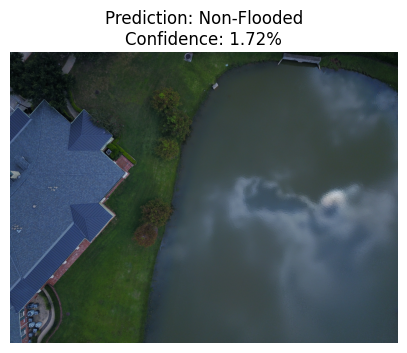

File: 7749.jpg
Predicted class: Non-Flooded (confidence: 1.72%)


In [30]:
sample_path = random.choice(X_test.index.map(lambda i: all_files[df.index.get_loc(i)]).tolist()) \
    if False else random.choice([all_files[i] for i in X_test.index])

feats = extract_dip_features(sample_path)
feats_df = pd.DataFrame([feats])

pred = rf_model.predict(feats_df)[0]
prob = rf_model.predict_proba(feats_df)[0][1]
pred_class = 'Flooded' if pred == 1 else 'Non-Flooded'

img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Prediction: {pred_class}\nConfidence: {prob:.2%}")
plt.axis('off')
plt.show()

print("File:", os.path.basename(sample_path))
print(f"Predicted class: {pred_class} (confidence: {prob:.2%})")

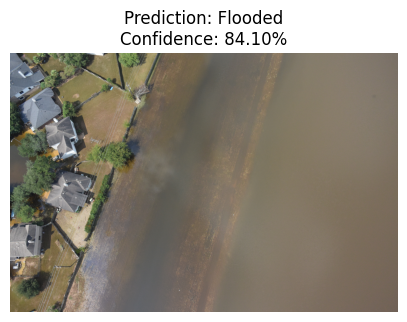

File: 7357.jpg
Predicted class: Flooded (confidence: 84.10%)


In [15]:
test_indices = X_test.index.tolist()
random_idx = random.choice(test_indices)
sample_path = all_files[random_idx]

feats = extract_dip_features(sample_path)
feats_df = pd.DataFrame([feats])

pred = rf_model.predict(feats_df)[0]
prob = rf_model.predict_proba(feats_df)[0][1]
pred_class = 'Flooded' if pred == 1 else 'Non-Flooded'

img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Prediction: {pred_class}\nConfidence: {prob:.2%}")
plt.axis('off')
plt.show()

print("File:", os.path.basename(sample_path))
print(f"Predicted class: {pred_class} (confidence: {prob:.2%})")